## 📄 Document, Image & Video Intelligence System with Gemini LLM

This project demonstrates a **multi-modal Generative AI system** built using **Google Gemini LLM** that can intelligently analyze **Documents (PDFs)**, **Images**, and **YouTube Videos** inside **Google Colab**.

The system is designed for **learning, demos, workshops, and real-world AI applications** such as document Q&A, visual understanding, and video summarization.

---

##  Features Overview

### ✅ Document Intelligence
- Upload or reference a **PDF document**
- Ask **natural language questions**
- Get **context-aware answers** from the document content

### ✅ Image Analysis
- Provide an **image URL**
- Ask questions about objects, text, or scenes in the image
- Gemini analyzes the image and responds intelligently

### ✅ Video Intelligence (YouTube)
- Paste a **YouTube video URL**
- Ask questions about events, actions, or summaries
- Gemini understands and reasons over the video

---


## Step:1 Configuration SetUp

In [ ]:
# @title Configuration Setup-->Run This Cell and Fill Your API-KEY

from google import genai
from google.genai import types
import httpx
from getpass import getpass

Gemini_API_Key = getpass('Enter Your Gemini API Key: ')

if Gemini_API_Key == "":
  print("Please Enter Your Gemini API Key and Press Run")
else:

  client = genai.Client(api_key=Gemini_API_Key)

  print("Configuration Setup Successful")




Enter Your Gemini API Key: ··········
Configuration Setup Successful



## Task:1 Document Intelligence System with Gemini LLM

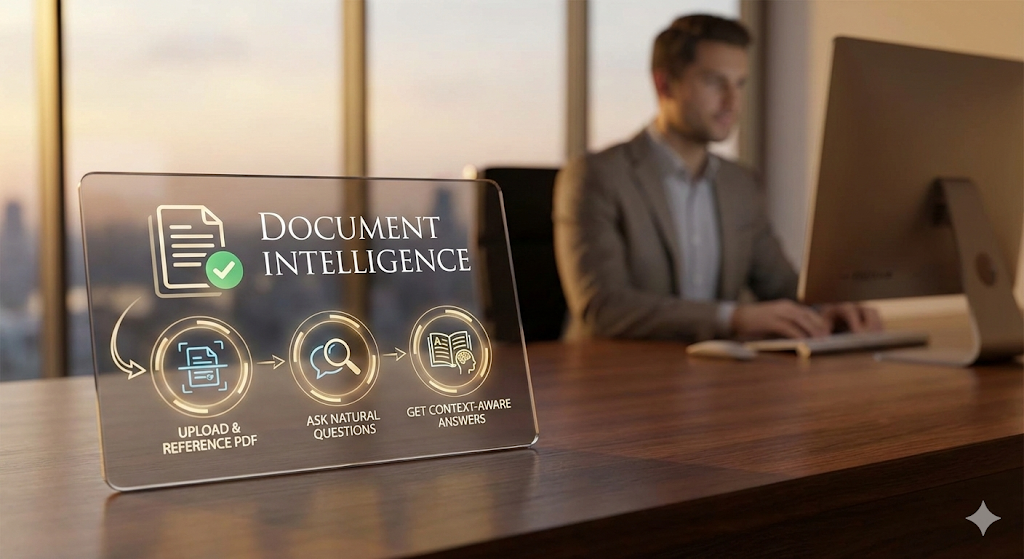

In [ ]:
# @title Block 1: Enter Document URL & Validate

import os
import pathlib
from IPython.display import display, Markdown

#  Enter your Document path / URL here
Document_URL = "/content/AirBnB Listings Data – Daily Work of a Data Team.ipynb - Colab.pdf"  # @param {"type":"string","placeholder":"Enter Your Document URL"}

if Document_URL == "":
    print("Please enter a Document URL")
elif os.path.exists(Document_URL):
    print("✅ Document Found:", Document_URL)
else:
    print("Invalid Document URL")


✅ Document Found: /content/AirBnB Listings Data – Daily Work of a Data Team.ipynb - Colab.pdf


In [ ]:
# @title  Block 2: Ask Questions About the Document

from IPython.display import display, Markdown
import pathlib # Added import
from google.genai import types # Added import for types

def Document_Intelligence_System(Document_URL, Question):

    filepath = pathlib.Path(Document_URL)

    prompt = types.Part.from_text(text=Question)

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[
            types.Part.from_bytes(
                data=filepath.read_bytes(),
                mime_type="application/pdf"
            ),
            prompt
        ]
    )

    display(Markdown(response.text))


#  Ask your question here
Question = "What is The Key Take Away in this Document?"  # @param {"type":"string","placeholder":"Ask Questions Based on the Document"}

if Document_URL == "": # Added check for Document_URL
    print("❌ Please enter a Document URL in the previous block (Block 1).")
elif Question == "":
    print("❌ Please enter a question")
else:
    Document_Intelligence_System(Document_URL, Question)

The key takeaway is that this document outlines a comprehensive, real-world data engineering and analysis workflow for an AirBnB data team.

The primary goal is to **transform complex, disparate, and often messy AirBnB listings data from multiple sources into a reliable, unified, and analysis-ready dataset to generate actionable business insights for pricing, growth, and trust teams.** It emphasizes data ingestion, quality, standardization, and subsequent market analysis, reflecting the daily operational work of a data professional.

## Task 2: Image Analysis System with Gemini LLM

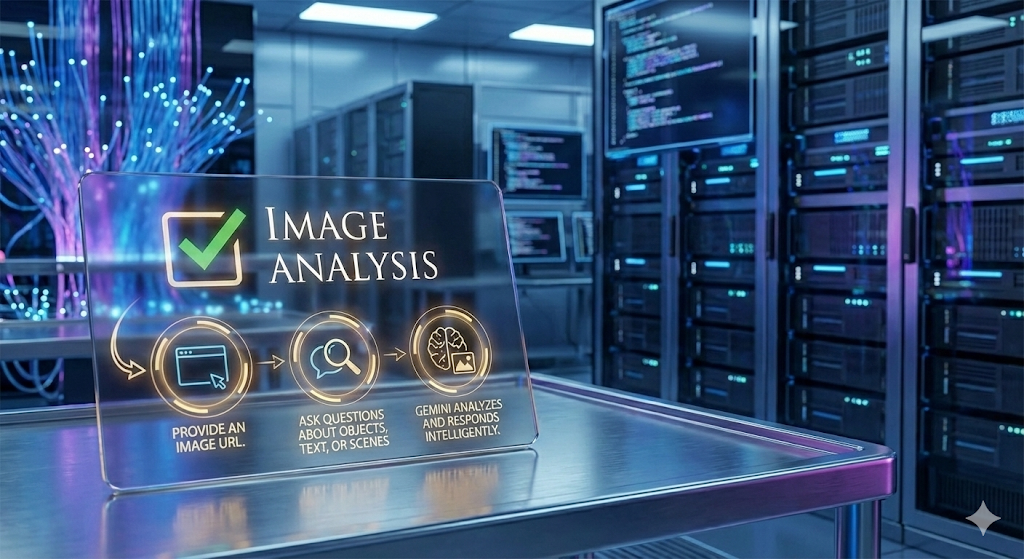

In [ ]:
# @title  Block 1: Enter Image URL & Display Image

import requests
from PIL import Image
from IPython.display import display
from io import BytesIO

# Enter your Image URL here
Image_URL = "https://images.unsplash.com/photo-1521737604893-d14cc237f11d"  # @param {"type":"string","placeholder":"Enter Image URL"}

if Image_URL == "":
    print(" Please enter an Image URL")
else:
    response = requests.get(Image_URL)
    if response.status_code == 200:
        image_bytes = response.content
        display(Image.open(BytesIO(image_bytes)))
        print("Image Loaded Successfully")
    else:
        print("Invalid Image URL")


Buffered data was truncated after reaching the output size limit.

In [ ]:
# @title Block 2: Ask Questions About the Image

from IPython.display import Markdown, display
import requests
from io import BytesIO
from google.genai import types # Ensure 'types' is imported for genai calls

def Image_Analysis_System(Image_URL, Question):
    # Added error handling for requests.get to prevent crashes on invalid URLs or network issues
    try:
        image_bytes = requests.get(Image_URL).content
    except requests.exceptions.MissingSchema:
        print(f"Invalid Image URL: '{Image_URL}' is missing a scheme (e.g., 'http://' or 'https://').")
        return
    except requests.exceptions.ConnectionError:
        print(f"Connection error while trying to access '{Image_URL}'. Please check the URL and your network connection.")
        return
    except Exception as e:
        print(f"An unexpected error occurred while fetching the image: {e}")
        return

    image_part = types.Part.from_bytes(
        data=image_bytes,
        mime_type="image/jpeg" # Assuming most images will be jpeg or can be converted.
    )

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[
            types.Part.from_text(text=Question),
            image_part
        ]
    )

    display(Markdown(response.text))


# Ask your question here
Question = "What Is the product mention in this Image" # @param {"type":"string","placeholder":"Ask questions about the image"}

# Add a check for Image_URL being empty before proceeding
if not Image_URL:
    print("Please provide an Image URL in the previous cell (Block 1) and run it.")
elif Question == "":
    print("Please enter a question")
else:
    Image_Analysis_System(Image_URL, Question)

The product mentioned in the image's infographic section is a **2-in-1 Rechargeable Air Duster & Vacuum Cleaner** by the brand **SUNPOLLO**.

## Task 3: Video Analysis Agent with Gemini LLM

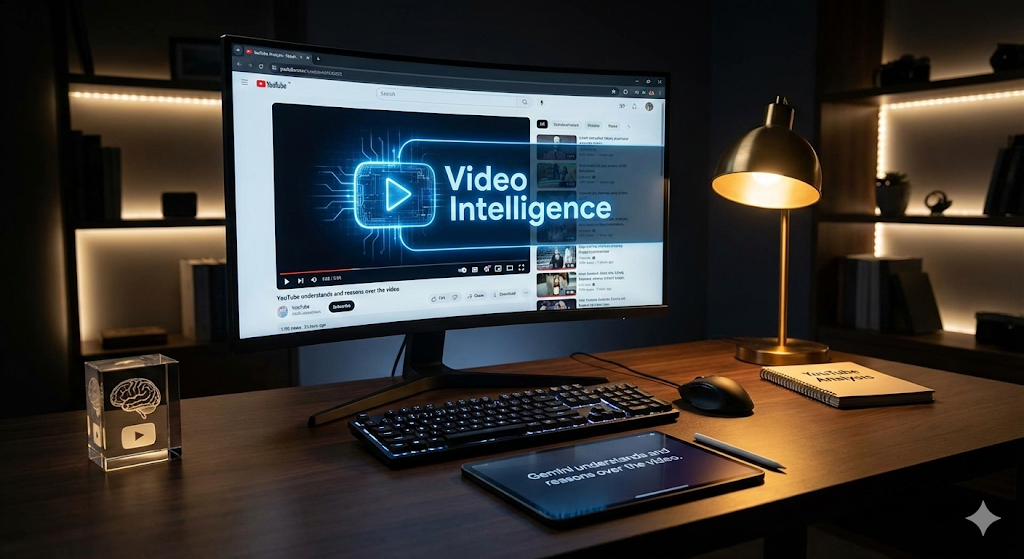

In [ ]:
# @title  Block 1: Enter YouTube URL & Validate

from urllib.parse import urlparse

# 👉 Enter your YouTube video URL here
Video_URL = "https://youtube.com/shorts/npdserGgrms?si=J96b2RcNdp9csJhj"  # @param {"type":"string","placeholder":"Enter YouTube Video URL"}

def is_valid_youtube_url(url):
    parsed = urlparse(url)
    return parsed.netloc in ["www.youtube.com", "youtube.com", "youtu.be"]

if Video_URL == "":
    print("❌ Please enter a YouTube URL")
elif is_valid_youtube_url(Video_URL):
    print("✅ Valid YouTube URL:", Video_URL)
else:
    print("❌ Invalid YouTube URL")


✅ Valid YouTube URL: https://youtube.com/shorts/npdserGgrms?si=J96b2RcNdp9csJhj


In [ ]:
# @title  Block 2: Ask Questions About the Video

from IPython.display import Markdown, display

def Video_Intelligence_System(Video_URL, Question):

    response = client.models.generate_content(
        model="models/gemini-2.5-flash",
        contents=types.Content(
            parts=[
                types.Part(
                    file_data=types.FileData(
                        file_uri=Video_URL
                    )
                ),
                types.Part(
                    text=Question
                )
            ]
        )
    )

    display(Markdown(response.text))


# 👉 Ask your question here
Question = "Show me the Details about this Video on each Time Stamp"  # @param {"type":"string","placeholder":"Ask Questions Based on the Video"}

if Question == "":
    print("❌ Please enter a question")
else:
    Video_Intelligence_System(Video_URL, Question)


Here's a detailed breakdown of the video content at each timestamp:

*   **0:00 - 0:01**: The video opens with a man in a black hoodie looking directly at the camera with an intense expression. Above him, the text "KYA HOGA?" (What will happen?) is displayed in yellow and red, setting up a question for the viewer.
*   **0:01 - 0:04**: The man gestures towards an Apple logo on the wall behind him. An animated graphic appears showing various Apple products (Mac Pro, Studio Display, iPad Mini, AirPods Max, AirPods Pro, iPhone 15 Pro, Apple TV 4K, Siri Remote) falling into a shopping cart. The man says, "Agar main Apple ke saare products cart mein add kar leta hoon?" (What if I add all Apple products to the cart?)
*   **0:04 - 0:06**: The man is back at his computer, money (in the form of dollar bills) animatedly flies around him. He smiles and says, "Aaj dekhte hai kitne ka bill banta hai." (Let's see how much the bill comes to today.)
*   **0:06 - 0:10**: A close-up shot shows the man's hand using a mouse to navigate the Apple website on an iMac. He clicks on an "iPhone 16 Pro Max" (a speculative model) with 1TB storage and adds it to the bag. An animated image of the iPhone 16 Pro Max appears on the wall above the monitor. He mentions starting with the "Pro model."
*   **0:10 - 0:14**: The man continues to add more iPhone models: "iPhone 16 Plus," "15 Plus," "14 Plus," and "iPhone SE." Animated images of these phones appear on the wall as he adds them. He explicitly states, "Sab khareed lete hai." (Let's buy them all.)
*   **0:14 - 0:17**: He adds Apple's high-end computers: an iMac, a Mac Studio, and a Mac Pro. Animated images of these devices pop up on the wall.
*   **0:17 - 0:19**: He proceeds to add various iPad models: an iPad Pro, an iPad Air, a standard iPad, and an iPad Mini. Animated images of the iPads appear on the wall.
*   **0:19 - 0:20**: He adds multiple Apple Watch models. An animated Apple Watch appears on the wall.
*   **0:20 - 0:24**: The man adds AirPods, then the Apple TV 4K with its remote, followed by a HomePod and a HomePod Mini. Animated images of these accessories appear on the wall.
*   **0:24 - 0:26**: The man is back in front of the computer, looking satisfied. An animated shopping cart graphic appears with the number "15" inside it. He states, "Saare products add ho chuke hai." (All products have been added.)
*   **0:26 - 0:29**: A close-up of the iMac screen reveals the total cost: ₹70,65,800.00 (approximately 70.65 lakh Indian Rupees). The man points to the total, and the text "70 LAKH" is overlaid on the screen.
*   **0:29 - 0:33**: He then points to a "Total savings" amount of ₹7,39,272.00 (approximately 7.39 lakh Indian Rupees) for eligible cards. The text "7 LAKH" is overlaid. He highlights this as the "most interesting बात" (most interesting thing), mentioning the significant discount.
*   **0:33 - 0:39**: The man concludes the video, smiling and gesturing towards the camera. He summarizes, "Toh agar aapko saare Apple products use karne hai, toh 70 lakh rupees spend karne padenge." (So, if you want to use all Apple products, you'll have to spend 70 lakh rupees.)